# train

## import

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from stable_baselines3 import PPO
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict

## train

In [5]:
food_reward_list = [1000, 1100, 1200, 1300, 1400]
att_coeff = 0.087213 #0.087213
att_temp = 0.25 # 0.25
penalty_cost = -30 #  -30
time_in_game_reward = 0. # old 0
# num_epochs = 11
# seed_value = 1

## food reward as a paramter input

In [40]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel


food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
num_epochs = 44
seed_value = 1

# for food_reward in food_reward_list:
#     task=AF()
#     task.food_reward=food_reward
#     model = PPO('MlpPolicy', task, verbose=1)
#     model.learn(total_timesteps=100)

task=AFR()
task.food_reward=1500
task.food_reward_list=food_reward_list
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [43]:
# train
for i in range(11):
    model.learn(total_timesteps=2222)

    # eval
    history_r=defaultdict(list)
    for _ in range(222):
        t=0
        total_r=0
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r
        # print(total_r)
        history_r[taskbelief.env.food_reward].append(total_r)
    for k,v in history_r.items():
        _=plt.hist(v, bins=22, label=k)
    plt.legend()
    plt.title(f'epoch {i}')
    plt.show()

## confirm the wrapper working for old env

In [38]:


food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
num_epochs = 44
seed_value = 1

# for food_reward in food_reward_list:
#     task=AF()
#     task.food_reward=food_reward
#     model = PPO('MlpPolicy', task, verbose=1)
#     model.learn(total_timesteps=100)

task=AF()
task.food_reward=1500
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


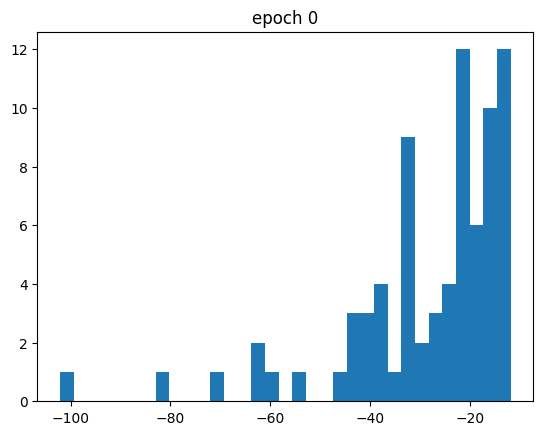

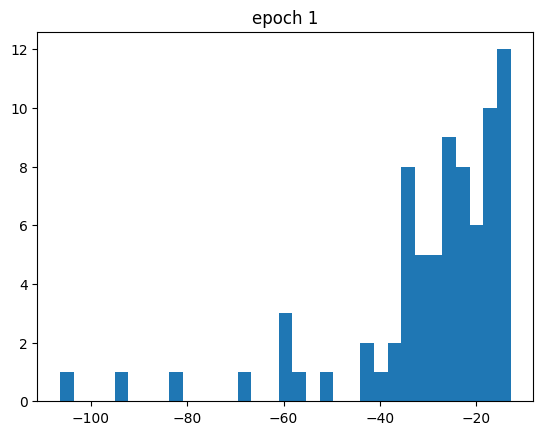

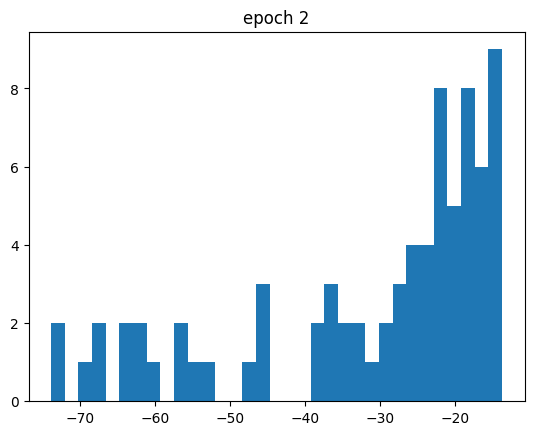

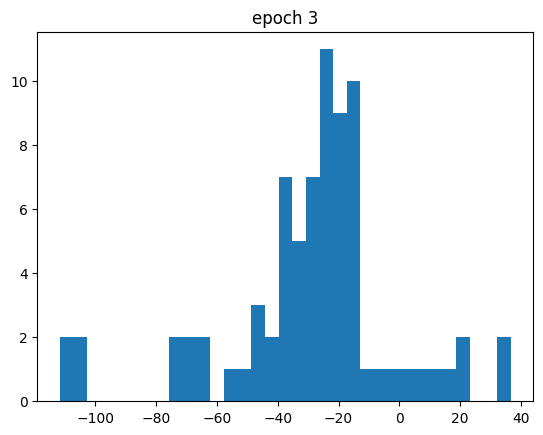

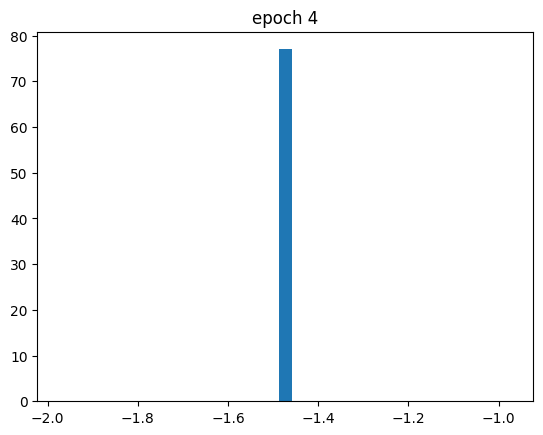

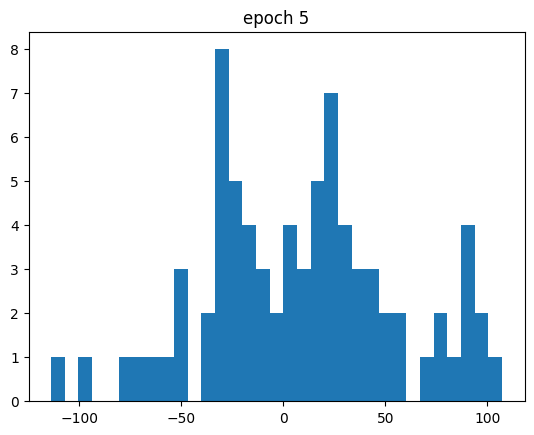

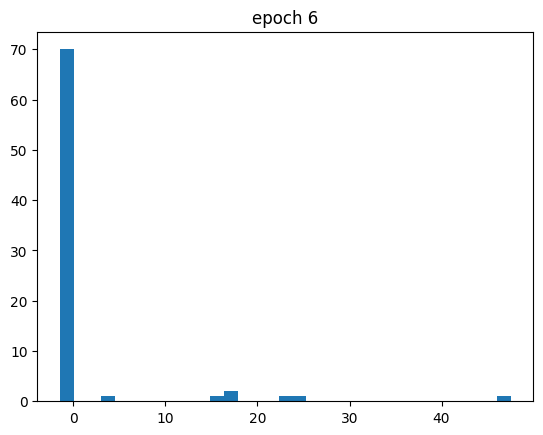

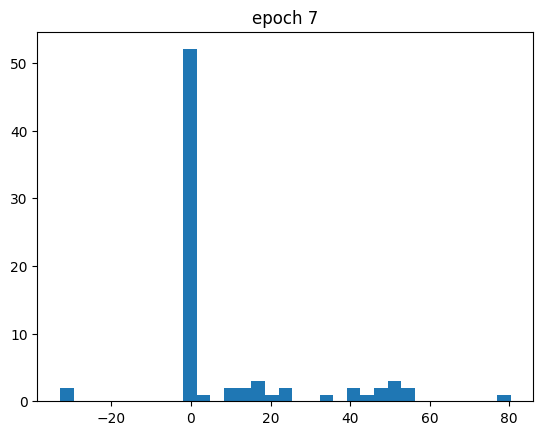

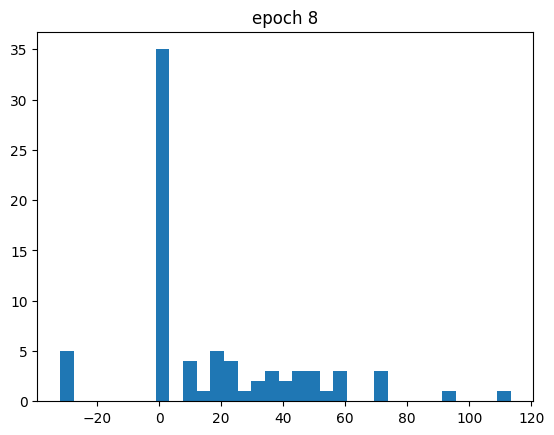

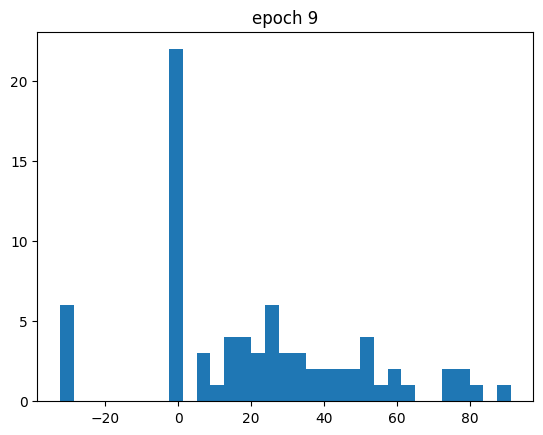

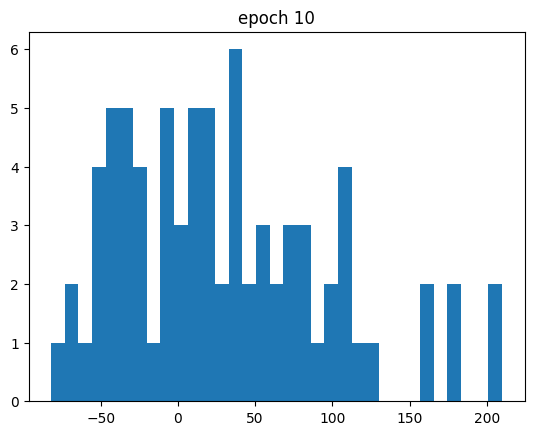

In [39]:
# train
for i in range(11):
    model.learn(total_timesteps=2222)

    # eval
    history_r=[]
    for _ in range(77):
        t=0
        total_r=0
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r
        # print(total_r)
        history_r.append(total_r)

    _=plt.hist(history_r, bins=33)
    # history_r 
        # print(task.food_reward)
    plt.title(f'epoch {i}')
    plt.show()

In [12]:
# baseline test
task=AF()
task.food_reward=1000
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
model = PPO('MlpPolicy', task, verbose=1, device='cpu')
model.learn(total_timesteps=9999/25*3600*1)
# model.save('ycstore/8hrtest')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 36.5          |
|    ep_rew_mean          | -3.48         |
| time/                   |               |
|    fps                  | 132           |
|    iterations           | 403           |
|    time_elapsed         | 6244          |
|    total_timesteps      | 825344        |
| train/                  |               |
|    approx_kl            | 0.00048051393 |
|    clip_fraction        | 0.00562       |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.287        |
|    explained_variance   | 0.00228       |
|    learning_rate        | 0.0003        |
|    loss                 | 84.2          |
|    n_updates            | 4020          |
|    policy_gradient_loss | -0.000665     |
|    value_loss           | 188           |
--------------------------

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.95     |
|    ep_rew_mean     | -12.2    |
| time/              |          |
|    fps             | 802      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.36        |
|    ep_rew_mean          | -22         |
| time/                   |             |
|    fps                  | 227         |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.020372465 |
|    clip_fraction        | 0.199       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.37       |
|    explained_variance   | 0.000421    |
|    learning_rate        | 0.

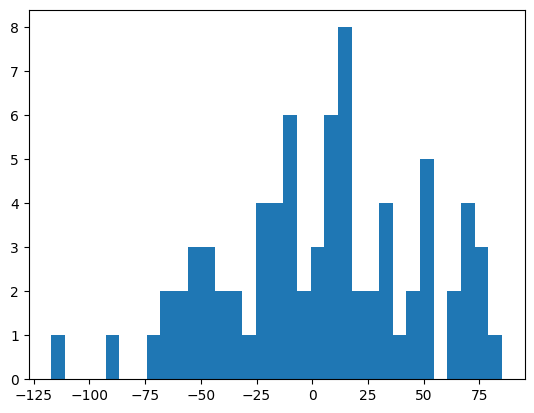

In [31]:
from collections import defaultdict
history_r=[]

for _ in range(77):
    t=0
    total_r=0
    x=taskbelief.reset()  
    done=False
    while not done: 
        # model.predict(x)
        a,_=model.predict(x,deterministic=True)
        x, r, done, _ = taskbelief.step(a)
        # print(x, r,task.food_reward)
        t+=1
        total_r+=r
    # print(total_r)
    history_r.append(total_r)
_=plt.hist(history_r, bins=33)
# history_r 
    # print(task.food_reward)


In [76]:
task=AFR()
task.food_reward_list=food_reward_list
model = PPO('MlpPolicy', task, verbose=1, device='cpu')
model.learn(total_timesteps=9999/25*3600*1)
# model.save('ycstore/8hrtest')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.93     |
|    ep_rew_mean     | -45.6    |
| time/              |          |
|    fps             | 765      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.52        |
|    ep_rew_mean          | -45.6       |
| time/                   |             |
|    fps                  | 570         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013881185 |
|    clip_fraction        | 0.192       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000308    |
|    learning_rate        | 0.

KeyboardInterrupt: 

## load and eval

In [70]:
task=AFR()
task.food_reward_list=food_reward_list
model = PPO.load(f'ycstore/8hrtest', env=task, device='cpu')

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [20]:
from collections import defaultdict
history_r=defaultdict(list)

for _ in range(5*999):
    t=0
    total_r=0
    x=taskbelief.reset()  
    done=False
    while not done: 
        # model.predict(x)
        a,_=model.predict(x)
        x, r, done, _ = taskbelief.step(a)
        # print(x, r,task.food_reward)
        t+=1
        total_r+=r
    history_r[taskbelief.env.food_reward].append(total_r/t)  
    # print(task.food_reward)


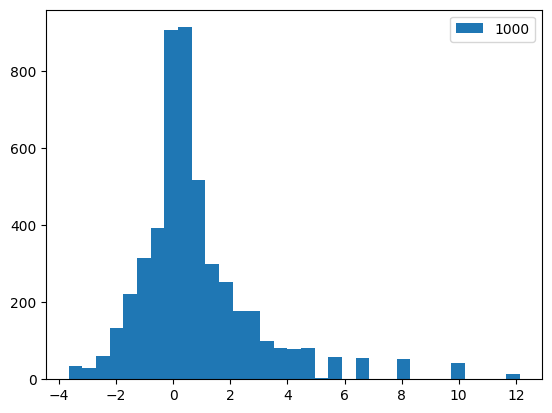

In [21]:
for food_reward,reward_rate in history_r.items():
    plt.hist(reward_rate,bins=33, label=food_reward)
    # plt.title(food_reward)
    # plt.show()
plt.legend()
    


avalible reward conditions [1000]


ValueError: List of boxplot statistics and `positions` values must have same the length

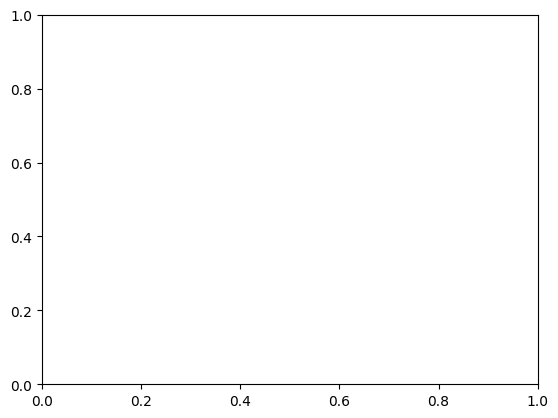

In [22]:
plt.figure()
thisdata=[]
thisx=[]
for food_reward,reward_rate in history_r.items():
    thisx.append(food_reward)
    thisdata.append(reward_rate)

print('avalible reward conditions',thisx)
plt.boxplot(thisdata, showfliers=False, positions=np.arange(5)+1)
plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
plt.xlabel('food reward')
plt.ylabel(f'Number of high attention time instances')
plt.title(f'Boxlplot - Number of high attention time instances Vs food rewawrds')
plt.show()